In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import corner
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Get the current working directory
current_path = os.getcwd()
# Get the parent directory
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
from class_analysis import metrics_creator

from class_analysis import plot_roman_rubin_plt
from class_analysis import create_df_to_plot
from class_analysis import graph_maker_1plot
from tqdm.auto import tqdm
from read_save import read_data

from ssh_connect import ssh_che
from connect_CHE import download_data

Parent Directory: /home/anibal/microlensing/simulation_Rubin/roman_rubin


In [2]:
model = 'FSPL'
path= parent_directory+f'/all_results/{model}_last/'
fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
true = pd.read_parquet(path+"/true.parquet")
met_1_rr, met_2_rr, met_3_rr = metrics_creator(true,fit_rr, model)
met_1_roman, met_2_roman, met_3_roman = metrics_creator(true,fit_roman, model)

Filas después del merge: 43398
Filas después del merge: 43398


# How does it look the true parameters of the simulation

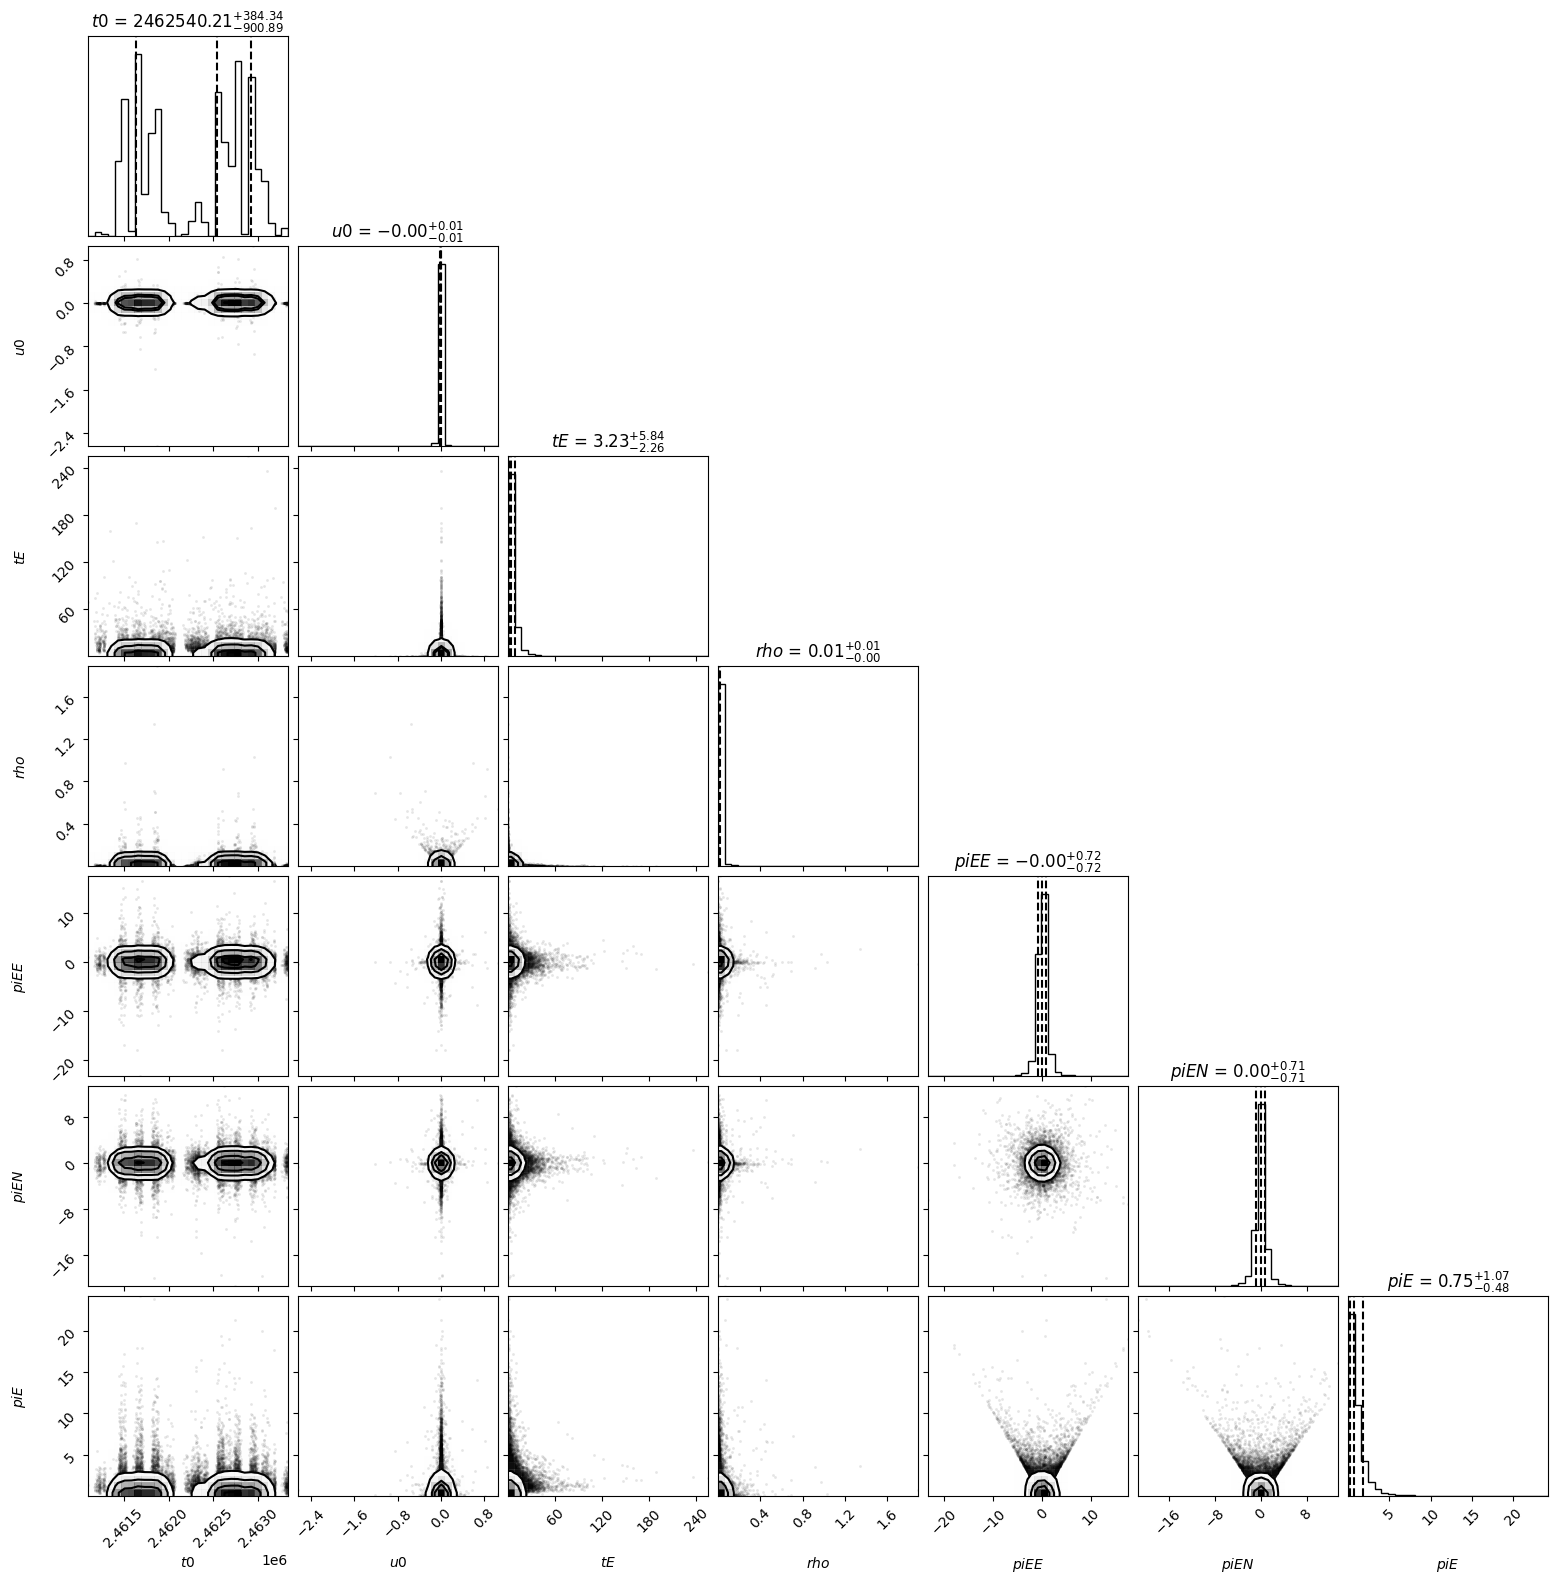

In [3]:
param_names = ['t0', 'u0', 'tE', 'rho', 'piEE', 'piEN', 'piE']
samples = true[param_names].values

figure = corner.corner(samples,
                       labels=[f"${p}$" for p in param_names],
                       bins=30, smooth=1.0,
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True,
                       title_fmt=".2f")

plt.show()

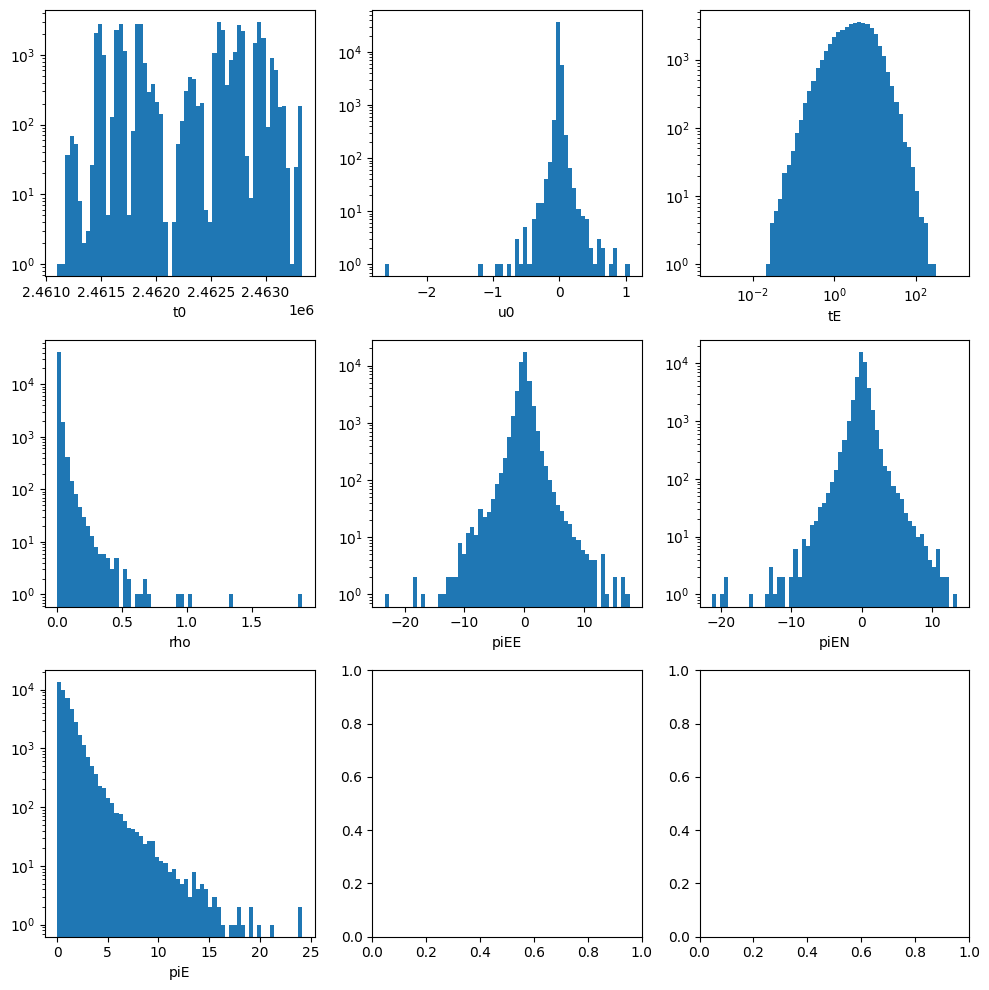

In [4]:
fig,axes = plt.subplots(3,3,figsize=(10,10),dpi=100)
axes = axes.flatten()
for i,p in enumerate(param_names):
    
    axes[i].set_xlabel(p)
    
    if p =='tE':
        bines = np.logspace(-3,3,60)
        axes[i].set_xscale("log")
        
    else:
        bines = 60
    axes[i].set_yscale("log")
    axes[i].hist(true[p],bins=bines)        
    # print(i,p)

plt.tight_layout()

# Split in for categories

In [5]:
cat_A = true[
    (true['W149_peak'] != 0) &
    (
        (true['u_peak'] != 0) |
        (true['g_peak'] != 0) |
        (true['r_peak'] != 0) |
        (true['i_peak'] != 0) |
        (true['z_peak'] != 0) |
        (true['y_peak'] != 0)
    )
]

cat_B = true[
    (true['W149_peak'] == 0) &
    (
        (true['u_peak'] != 0) |
        (true['g_peak'] != 0) |
        (true['r_peak'] != 0) |
        (true['i_peak'] != 0) |
        (true['z_peak'] != 0) |
        (true['y_peak'] != 0)
    )
]

cat_C = true[
    (true['W149_peak'] != 0) &
    (
        (true['u_peak'] == 0) &
        (true['g_peak'] == 0) &
        (true['r_peak'] == 0) &
        (true['i_peak'] == 0) &
        (true['z_peak'] == 0) &
        (true['y_peak'] == 0)
    )
]
cat_D = true[
    (true['W149_peak'] == 0) &
    (
        (true['u_peak'] == 0) &
        (true['g_peak'] == 0) &
        (true['r_peak'] == 0) &
        (true['i_peak'] == 0) &
        (true['z_peak'] == 0) &
        (true['y_peak'] == 0)
    )
]

print((len(cat_A)+len(cat_B)+len(cat_C)+len(cat_D))==len(true))
print(len(cat_A)/len(true))
print(len(cat_B)/len(true))
print(len(cat_C)/len(true))

True
0.29190285266602145
0.15956956541776118
0.5485275819162173


In [6]:
fit_rr_A = fit_rr.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')
fit_roman_A = fit_roman.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met1_rr_A = met_1_rr.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met1_roman_A = met_1_roman.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met2_rr_A = met_2_rr.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met2_roman_A = met_2_roman.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met3_rr_A = met_3_rr.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met3_roman_A = met_3_roman.merge(cat_A[['Source', 'Set']], on=['Source', 'Set'], how='inner')


fit_rr_B = fit_rr.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')
fit_roman_B = fit_roman.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met1_rr_B = met_1_rr.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met1_roman_B = met_1_roman.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met2_rr_B = met_2_rr.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met2_roman_B = met_2_roman.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met3_rr_B = met_3_rr.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met3_roman_B = met_3_roman.merge(cat_B[['Source', 'Set']], on=['Source', 'Set'], how='inner')


fit_rr_C = fit_rr.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')
fit_roman_C = fit_roman.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met1_rr_C = met_1_rr.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met1_roman_C = met_1_roman.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met2_rr_C = met_2_rr.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met2_roman_C = met_2_roman.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')

met3_rr_C = met_3_rr.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')
met3_roman_C = met_3_roman.merge(cat_C[['Source', 'Set']], on=['Source', 'Set'], how='inner')


# we can ask if there is an improovement in the relative error, the bias or the ratio between the bias and the uncertainty in the parameter as a function of the fraction of parameters that improve in a certain threshold

We can observe in this plot that there are events tha improve its bias and other than increase it when Rubin data is added

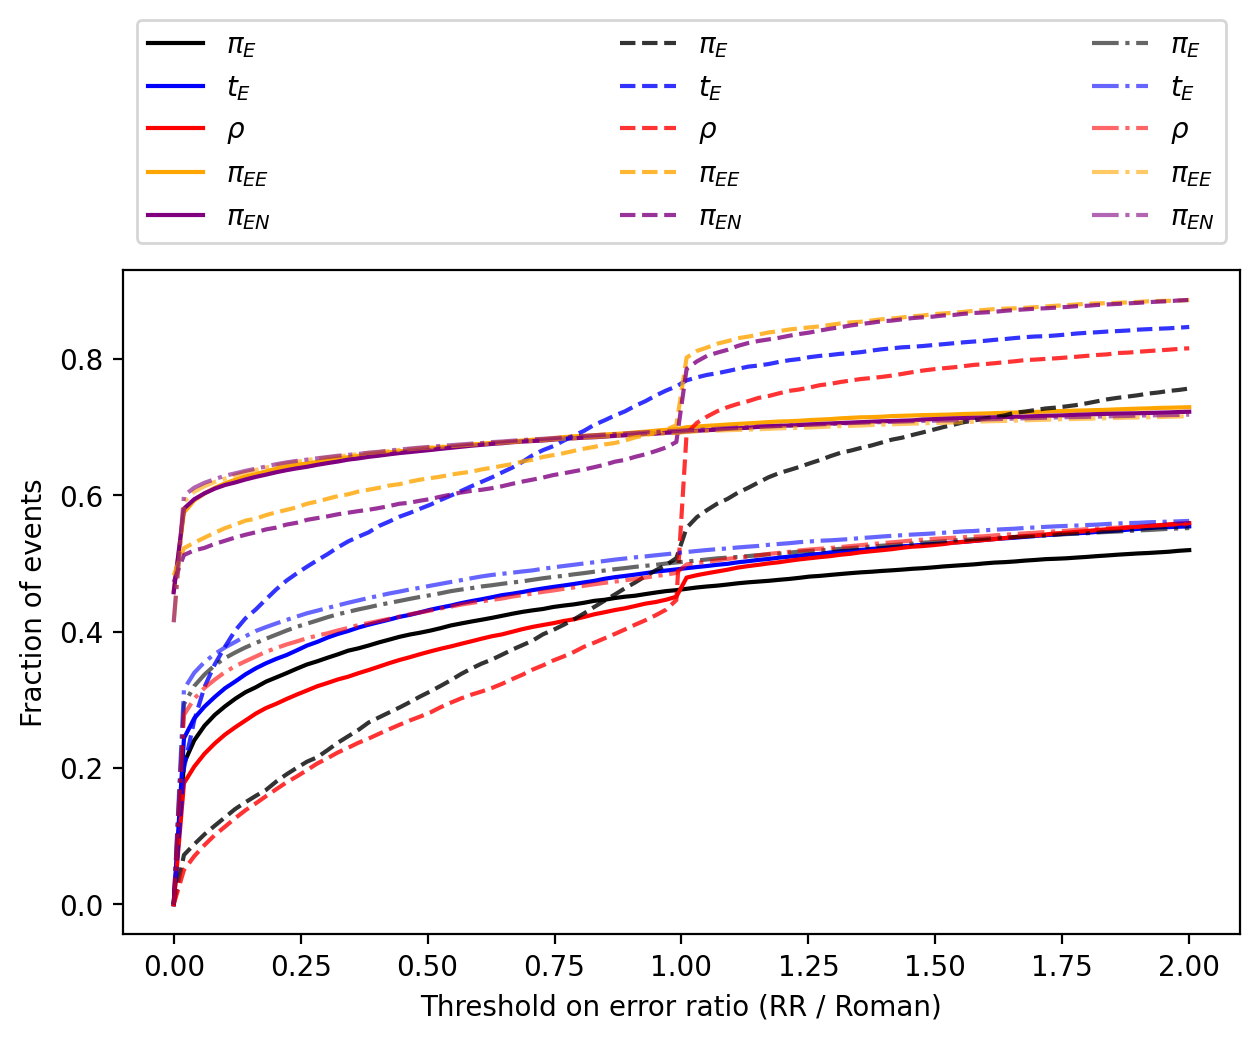

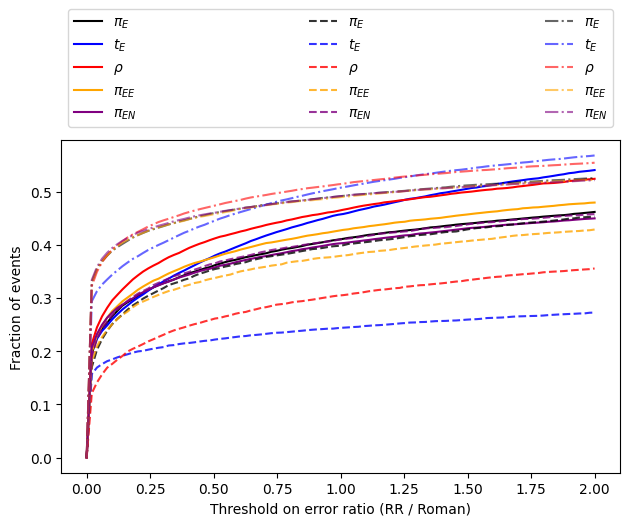

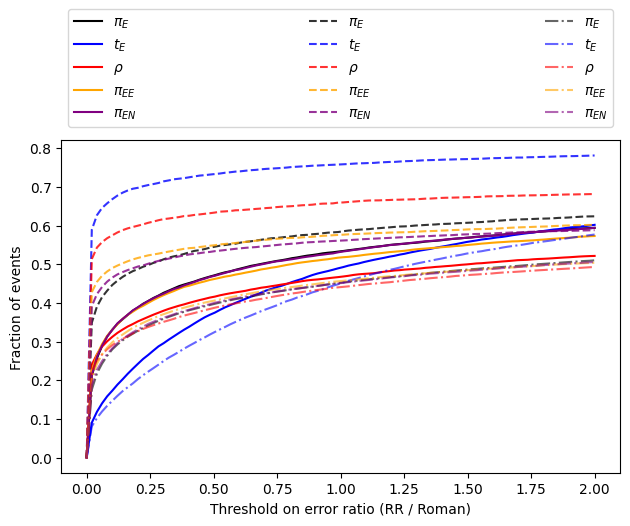

In [8]:
plt.figure(dpi=200)
label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}

CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']

for k,met in enumerate([[met_1_rr,met_1_roman],[met_2_rr,met_2_roman],[met_3_rr,met_3_roman]]):
    for i,cat in enumerate([cat_A,cat_B,cat_C]):
        m_rr = met[0].merge(cat[['Source', 'Set']], on=['Source', 'Set'], how='inner')
        m_roman = met[1].merge(cat[['Source', 'Set']], on=['Source', 'Set'], how='inner')
        if i == 0:
            line = '-'
            alph=1
        elif i==1:
            line = '--'
            alph=0.8
        elif i==2:
            line = '-.'
            alph=0.6
            
        for j,p in enumerate(['piE','tE','rho','piEE','piEN']):
            ratio = m_rr[p]/m_roman[p]
            fraction = []
            thresh = np.linspace(0,2,100)
            for alpha in thresh:
                fraction.append(len(ratio[ratio<alpha])/len(ratio))
    
            plt.plot(thresh,fraction,color = CLR[j],linestyle=line,label=label_dict[p],alpha=alph)
            plt.xlabel("Threshold on error ratio (RR / Roman)")
            plt.ylabel('Fraction of events')
    
    
    plt.legend(loc='best',ncols=3,mode="expand",bbox_to_anchor=(0, 1.02, 1, 0.2))
    plt.tight_layout()
    path_save_fig = '/home/anibal/figures_paper_romanrubin/'
    plt.savefig(path_save_fig+f'threshold_{label_met[k]}_{model}.png')
    plt.show()

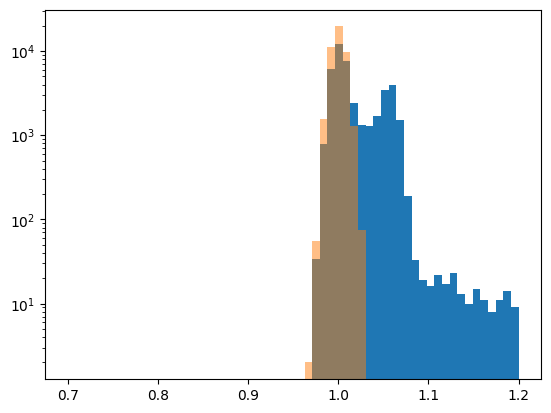

In [9]:
plt.hist(fit_rr['chichi']/fit_rr['dof'],bins=np.linspace(0.7,1.2,60))
plt.hist(fit_roman['chichi']/fit_roman['dof'],bins=np.linspace(0.7,1.2,60),alpha=0.5)
plt.yscale('log')
# plt.xscale('log')

In [14]:
met_1_roman

,id,Source,Set,t0,u0,tE,rho,piEN,piEE,piE
0,75689,65689,1,1.982763e-11,0.011354,0.000034,0.558880,-0.006359,-0.000197,0.000008
1,10023,23,1,7.667737e-07,-0.998922,0.272006,1.000000,-0.004789,-1.000000,0.083633
2,42929,32929,1,4.059596e-06,0.939418,0.898405,0.704280,-0.957490,-0.948688,0.955461
3,10049,49,1,4.059892e-06,1.000000,1.000000,1.000000,-1.000000,-0.073768,0.154361
4,75631,65631,1,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
56505,62763,32763,3,1.845292e-10,-0.000166,0.000219,0.002973,-0.000997,-0.000142,0.000087
56506,62745,32745,3,6.033290e-07,-0.999997,0.011824,0.997670,-1.000000,-0.201492,0.203509
56507,95532,65532,3,5.570076e-10,-0.039332,0.006140,0.047916,0.041962,-0.000173,0.000208
56508,62753,32753,3,1.104253e-07,-0.085046,0.009582,0.136932,0.118071,-0.004674,0.047538


In [45]:
def compute_ratio_by_keys(df1, df2, value_col='piE', key_cols=('Source', 'Set')):
    """
    Merge two DataFrames on key columns and compute the ratio of value_col from df2 over df1.

    Parameters:
    -----------
    df1, df2 : pd.DataFrame
        DataFrames containing the value_col and key_cols.
    value_col : str
        The column to compute the ratio from.
    key_cols : tuple
        The columns used to merge the dataframes (must uniquely identify rows).

    Returns:
    --------
    result : pd.DataFrame
        A DataFrame with key columns and the computed ratio in a 'ratio' column.
    """
    import pandas as pd
    import warnings

    # Validar columnas necesarias
    for df_name, df in zip(['df1', 'df2'], [df1, df2]):
        for col in list(key_cols) + [value_col]:
            if col not in df.columns:
                raise ValueError(f"Column '{col}' not found in {df_name}")

    # Cantidades iniciales
    initial_rows_df1 = len(df1)
    initial_rows_df2 = len(df2)

    # Selección de columnas y merge
    columns_to_select = list(key_cols) + [value_col]
    merged = pd.merge(
        df1[columns_to_select],
        df2[columns_to_select],
        on=list(key_cols),
        suffixes=('_df1', '_df2'),
        how='inner'
    )

    # Reportar pérdidas por el merge
    merged_rows = len(merged)
    lost_rows_df1 = initial_rows_df1 - merged_rows
    lost_rows_df2 = initial_rows_df2 - merged_rows
    if lost_rows_df1 > 0 or lost_rows_df2 > 0:
        warnings.warn(
            f"{lost_rows_df1} filas de df1 y {lost_rows_df2} filas de df2 se perdieron en el merge por claves no coincidentes."
        )

    # Advertir sobre ceros en el denominador
    denom_zeros = (merged[f"{value_col}_df1"] == 0).sum()
    if denom_zeros > 0:
        warnings.warn(f"{denom_zeros} denominadores iguales a cero. El ratio será NaN en esas filas.")

    # Calcular el ratio
    merged["ratio"] = merged[f"{value_col}_df2"] / merged[f"{value_col}_df1"]

    # Devolver claves y ratio
    return merged[list(key_cols) + ["ratio"]]




/tmp/ipykernel_24002/2959320818.py:54: UserWarning: 2907 denominadores iguales a cero. El ratio será NaN en esas filas.
  warnings.warn(f"{denom_zeros} denominadores iguales a cero. El ratio será NaN en esas filas.")


In [80]:
# ratio_bias

In [70]:
# ratio_error

In [36]:
# plt.hist(met_1_roman['rho'], bins=np.logspace(-10,1,60))

Usando 39745 de 39876 filas para el histograma 2D.


/tmp/ipykernel_24002/2959320818.py:54: UserWarning: 49 denominadores iguales a cero. El ratio será NaN en esas filas.
  warnings.warn(f"{denom_zeros} denominadores iguales a cero. El ratio será NaN en esas filas.")


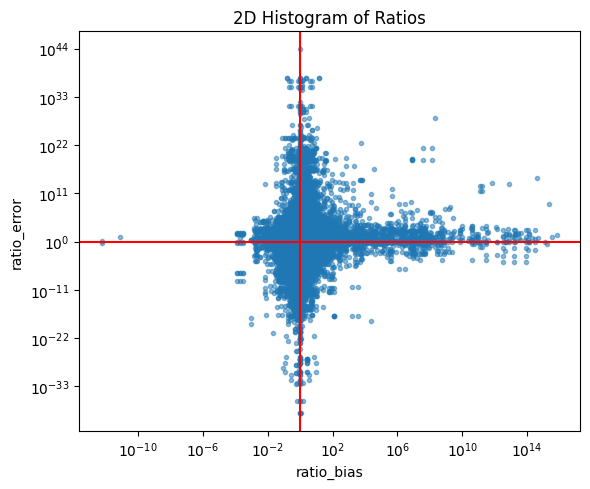

In [86]:
ratio_bias = compute_ratio_by_keys(met1_rr_B, met1_roman_B, value_col='piE', key_cols=('Source', 'Set'))
ratio_error = compute_ratio_by_keys(met3_rr_B, met3_roman_B, value_col='piE', key_cols=('Source', 'Set'))

# Merge para tener ambas razones por fila
merged = pd.merge(ratio_bias, ratio_error, on=['Source', 'Set'], suffixes=('_bias', '_error'))


# Eliminar filas con NaN o Inf en los ratios
filtered = merged.replace([np.inf, -np.inf], np.nan).dropna(subset=["ratio_bias", "ratio_error"])

print(f"Usando {len(filtered)} de {len(merged)} filas para el histograma 2D.")

# Histograma 2D
%matplotlib inline
plt.figure(figsize=(6, 5))
plt.scatter(filtered["ratio_bias"], filtered["ratio_error"],marker='.',alpha=0.5)
plt.axvline(1,color='red')
plt.axhline(1,color='red')
plt.xlabel("ratio_bias")
plt.ylabel("ratio_error")
# plt.colorbar(label="Counts")
plt.title("2D Histogram of Ratios")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()


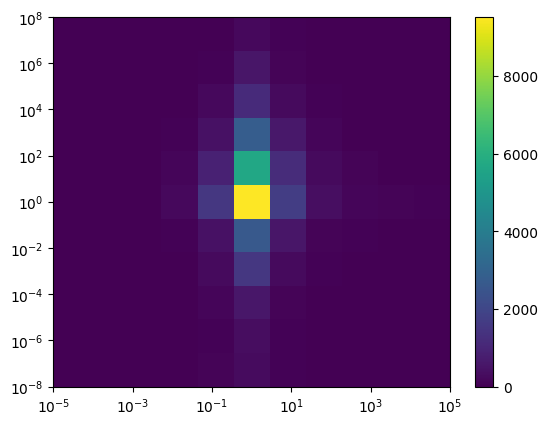

In [120]:
x = filtered["ratio_bias"].to_numpy()
y =  filtered["ratio_error"].to_numpy()

plt.hist2d(x,y, bins=(np.logspace(-5,5,12),np.logspace(-8,8,12)))
plt.yscale("log")
plt.xscale("log")
plt.colorbar()

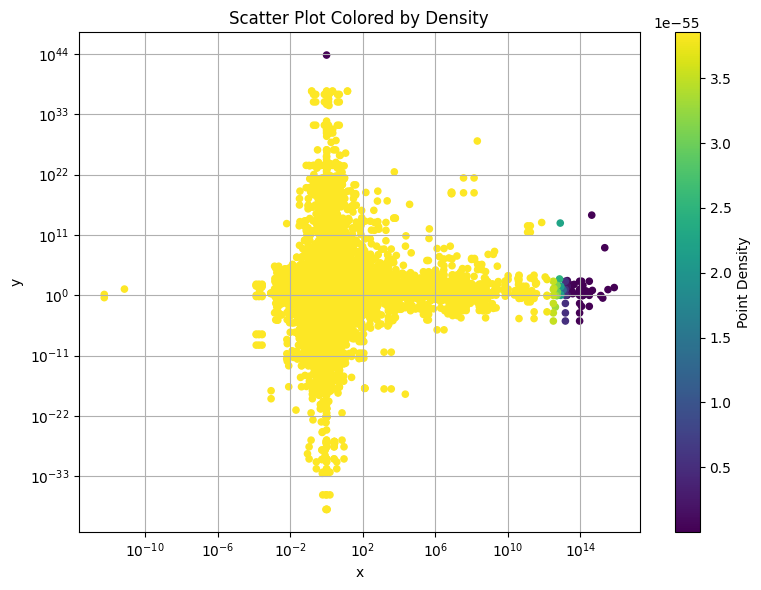

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generate sample data
x = filtered["ratio_bias"].to_numpy()
y =  filtered["ratio_error"].to_numpy()

# Calculate the point density
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, makes dense points plot on top)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

# Make the scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(x, y, c=z, s=20, cmap='viridis')
plt.colorbar(sc, label='Point Density')
plt.xlabel("x")
plt.ylabel("y")
plt.xscale("log")
plt.yscale("log")
plt.title("Scatter Plot Colored by Density")
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
# x1 = met_1_rr['piE'].reset_index(drop=True) #[true['crit_FFP_Rubin']==True]
# x2 = met_1_roman['piE'].reset_index(drop=True) #[true['crit_FFP_Rubin']==True]
# # print(x1,x2)
# ratio_bias = x2/x1
# y1 = met_3_rr['piE'].reset_index(drop=True)#[true['crit_FFP_Rubin']==True]
# y2 = met_3_roman['piE'].reset_index(drop=True)#[true['crit_FFP_Rubin']==True
# ratio_error = y2/y1
# # mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
# # mask_piE_uncertainty = met_1_roman[mask]['piE']<0.25
# # x = x[mask]
# # y = y[mask]
# plt.hist2d(ratio_bias,ratio_error,bins=(np.logspace(-4,4,60),np.logspace(-4,4,60)))
# fraction = 1
# plt.axhline(fraction,linestyle='--',color='red',linewidth=3.5,label='$ratio$ = 1')
# plt.axvline(fraction,linestyle='--',color='red',linewidth=3.5,label='$ratio$ = 1')
# plt.xlabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}}$',fontsize=30)
# plt.ylabel(r'$\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}$',fontsize=30)
# # plt.title('Characterization of parallax in FFP events with Roman.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_E}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(loc='best',fontsize=15)
# plt.colorbar()
# plt.show()

In [121]:
x = met_1_rr['piE']#[true['crit_FFP_Rubin']==True]
y = met_3_rr['piE']#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
mask_piE_sigma_smll_25 = met_3_rr[mask]['piE']<0.25
# met_1_rr[mask_piE_sigma_smll_25]

In [122]:
# Paso 1: construir x, y desde los DataFrames
x = met_1_rr['piE']
y = met_3_rr['piE']
# Paso 2: construir máscara común y aplicarla a ambos DataFrames
mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
# Paso 3: aplicar la máscara y resetear el índice para evitar desalineación
met_1_rr_masked = met_1_rr[mask].reset_index(drop=True)
met_3_rr_masked = met_3_rr[mask].reset_index(drop=True)
# Paso 4: crear una nueva máscara sobre met_3_rr filtrado
mask_piE_sigma_smll_25 = met_3_rr_masked['piE'] < 0.25
# Paso 5: aplicar esa máscara sobre met_1_rr ya filtrado
result = met_1_rr_masked[mask_piE_sigma_smll_25]

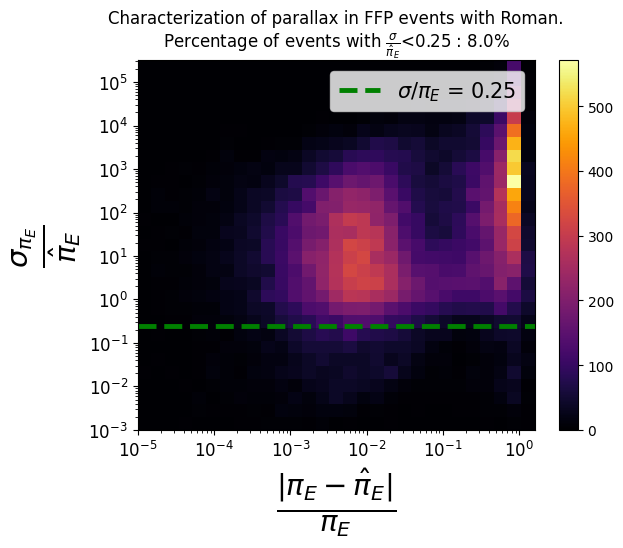

In [123]:
x = met_1_roman['piE']#[true['crit_FFP_Rubin']==True]
y = met_3_roman['piE']#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
mask_piE_uncertainty = met_1_roman[mask]['piE']<0.25
x = x[mask]
y = y[mask]
plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-3,5.5,30)),cmap='inferno')
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{E}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}$',fontsize=30)
plt.title('Characterization of parallax in FFP events with Roman.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_E}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar()
plt.show()

In [ ]:
x = met_1_rr['piEE']#[true['crit_FFP_Rubin']==True]
y = met_3_rr['piEE']#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
mask_piE_uncertainty = met_1_rr[mask]['piEE']<0.25
x = x[mask]
y = y[mask]
plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-3,5.5,30)),cmap='inferno')
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{EE}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{EE}-\hat{\pi}_{EE}|}{\pi_{EE}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{EE}}}{\hat{\pi}_{EE}}$',fontsize=30)
plt.title('Characterization of parallax in FFP events with Roman & Rubin.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_{EE}}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar()
plt.show()

In [ ]:
x = met_1_rr['piEN']#[true['crit_FFP_Rubin']==True]
y = met_3_rr['piEN']#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
mask_piE_uncertainty = met_1_rr[mask]['piEN']<0.25
x = x[mask]
y = y[mask]
plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-3,5.5,30)),cmap='inferno')
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{EN}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{EN}-\hat{\pi}_{EN}|}{\pi_{EN}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{EN}}}{\hat{\pi}_{EN}}$',fontsize=30)
plt.title('Characterization of parallax in FFP events with Roman & Rubin.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_{EN}}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar()
plt.show()

In [ ]:
x = met_1_roman['piEN']#[true['crit_FFP_Rubin']==True]
y = met_3_roman['piEN']#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
mask_piE_uncertainty = met_1_roman[mask]['piEN']<0.25
x = x[mask]
y = y[mask]
plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-3,5.5,30)),cmap='inferno')
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{EN}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{EN}-\hat{\pi}_{EN}|}{\pi_{EN}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{EN}}}{\hat{\pi}_{EN}}$',fontsize=30)
plt.title('Characterization of parallax in FFP events with Roman.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_{EN}}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(dpi=150)
plt.hist2d(true['tE'][(met_3_rr['piE']<0.25)], met_1_rr['piE'][met_3_rr['piE']<0.25], bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.title('Free Floating Planets',fontsize=20)
plt.colorbar()
plt.show()

In [ ]:
plt.hist(true['tE'], bins=np.logspace(-2,3,30))
plt.hist(true['tE'][(met_3_rr['piE']<0.5)],bins=np.logspace(-2,3,30))#, met_1_rr['piE'][met_3_rr['piE']<0.25],marker='.',linestyle='')#, bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.hist(true['tE'][(met_3_roman['piE']<0.5)],bins=np.logspace(-2,3,30))#, met_1_roman['piE'][met_3_roman['piE']<0.25],marker='.',linestyle='')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [ ]:
plt.figure(dpi=150)
plt.plot(true['tE'][(met_3_rr['piE']<0.25)], met_1_rr['piE'][met_3_rr['piE']<0.25],marker='.',linestyle='')#, bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.plot(true['tE'][(met_3_roman['piE']<0.25)], met_1_roman['piE'][met_3_roman['piE']<0.25],marker='.',linestyle='')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.title('Free Floating Planets',fontsize=20)
# plt.colorbar()
plt.show()

In [ ]:
plt.hist(true['tE'], bins=np.logspace(-2,3,30),rwidth=0.8)
plt.yscale('log')
plt.xscale('log')

In [ ]:
sources_crit5pts = true['Source'][true['crit_FFP_Rubin']==True].values
sources_crit5pts


x = met_1_rr['piE'][met_1_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
y = met_3_rr['piE'][met_3_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
# mask_piE_uncertainty = met_1_rr[mask]['piE']<0.25
x = x[mask]
y = y[mask]
plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-3,5.5,30)),cmap='inferno')
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{E}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}$',fontsize=30)
plt.title('Characterization of parallax in FFP events with Roman & Rubin.\nCriteria 5 Rubin points in [t0-tE,t0+tE]\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_E}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar()
plt.show()


In [ ]:
plt.figure(dpi=150)
plt.plot(true['tE'][(met_3_rr['piE']<0.25)], met_1_rr['piE'][met_3_rr['piE']<0.25],marker='o',linestyle='')#, bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.plot(true['tE'][(met_3_roman['piE']<0.25)], met_1_roman['piE'][met_3_roman['piE']<0.25],marker='o',linestyle='')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.title('Free Floating Planets',fontsize=20)
plt.show()

In [ ]:
cat_A

In [ ]:

n_nans = np.isnan(met3_roman_C['t0'].to_list()).sum()
n_nans

In [ ]:
31078-7588

In [ ]:
# met3_roman_C

In [ ]:
fit_roman_C[["Source","Set","u0","u0_err"]]

In [ ]:
1.575372/-0.010540 	

In [ ]:
cat_C[["Source","Set","u0"]]

In [ ]:
m3_test

In [ ]:
labelsparams = lambda p: labels[p]
label_m3 = lambda p :r'$\frac{\sigma_{'+f'{labels[p]}'+'}}{'+f'{labels[p]}'+'^{fit}}$'#+f'{labels[p]}'+'}}$'
label_m2 = lambda p :r'$\frac{|'+f'{labels[p]}'+'^{true}-'+f'{labels[p]}'+'^{fit}|}{\sigma_{'+f'{labels[p]}'+'}}$'
fig, ax = plt.subplots(1, 1, figsize = (12, 5), sharey=True, gridspec_kw={'width_ratios': [1]})
q='tE'
ax.plot(true['tE'],true['piE'],marker='o',ls='')#,bins=np.linspace(min(true[q]), max(true[q]),15))
ax.plot(true['tE'][true['Source'].isin(err_ratio['Source'][err_ratio['piE']<0.25])], true['piE'][true['Source'].isin(err_ratio['Source'][err_ratio['piE']<0.25])],marker='x',ls='',color='red',label='Events with\n'+r'$\frac{\sigma(\pi_E)_{RR}}{\sigma(\pi_E)_{Roman}}<0.25$')#,bins=np.linspace(min(true[q]), max(true[q]),15))
ax.set_xlabel(r'$t_E [days]$',fontsize=20)
ax.set_ylabel(r'$\pi_E$',fontsize=20)
ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)
# Histogram settings
#binwidth = 0.1
ax_histx.hist(true['tE'], bins=np.arange(0, 1000, 60), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='red')
ax_histx.hist(true['tE'][true['Source'].isin(err_ratio['Source'][err_ratio['piE']<0.25])], bins=np.arange(0, 1000, 60), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='blue')
ax_histy.hist(true['piE'], bins=np.arange(0, 0.15, 0.015), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')
ax_histy.hist(true['piE'][true['Source'].isin(err_ratio['Source'][err_ratio['piE']<0.25])], bins=np.arange(0, 0.15, 0.015), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='crimson', orientation='horizontal')
#ax_histy.set_xscale("log")
# Remove ticks from inset histograms
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(axis="y", left=False, labelleft=False)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
ax.legend(loc='best',fontsize=20)

In [ ]:
%matplotlib inline
plt.close("all")
def plot_histogram(ax, data, p, colors, some_flag=False):
    # print(data)
    sources = data['Source'].values
    data = data[p]   
    lab_latex = {'te':'tE(days)','rho':'\\rho' ,'piE':'\pi_E','q':'q'}
    data_label = lab_latex[p]
    lab_latex_legend = {'te':'t_E','rho':'\\rho','piE':'\pi_E','q':'q'}
    xlabel=r'$log_{10}'+f"[{lab_latex[p]}]$"
    
    masks_rr = lambda p, label: [
        (met_1_rr[p][met_1_rr['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_rr[p][met_2_rr['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_rr[p][met_3_rr['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    masks_roman = lambda p, label:[
        (met_1_roman[p][met_1_roman['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_roman[p][met_2_roman['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_roman[p][met_3_roman['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    
    if some_flag:
        masks = masks_roman(p,lab_latex_legend[p])
        dataset = 'Roman'
        met_1 = met_1_roman[met_1_roman['Source'].isin(sources)]
        met_2 = met_2_roman[met_2_roman['Source'].isin(sources)]
        met_3 = met_3_roman[met_3_roman['Source'].isin(sources)]
    else:
        masks = masks_rr(p,lab_latex_legend[p])
        dataset = 'Roman and Rubin'
        met_1 = met_1_rr[met_1_rr['Source'].isin(sources)]
        met_2 = met_2_rr[met_2_rr['Source'].isin(sources)]
        met_3 = met_3_rr[met_3_rr['Source'].isin(sources)]

    # Plot the histogram of the true values
    ax.hist(np.log10(data), bins=30, color='royalblue', alpha=0.5, label=f'True value of ${lab_latex_legend[p]}$')
    
    # Iterate over the masks and plot the masked data
    for (mask, color, label) in masks:
        # Select the masked data based on the condition in the mask
        # print(label)
        masked_data = data[mask]
        ax.hist(np.log10(masked_data), 
                bins=30, histtype='step', color=color, lw=2, label=label)
    
    # Set labels and title
    # print(xlabel)
    ax.set_xlabel(xlabel, fontsize=20)
    

    ax.set_title('Percentage of events with:\n'+
                 f"$\\alpha({lab_latex_legend[p]})<0.25: $"+
                 f"{round(100*len(met_1[p][met_1[p]<0.25])/len(data),2)}%, "+'\n'+
                 f"$\\beta({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_2[p][met_2[p]<0.25])/len(data),1)}%, "+'\n'+
                 f"$\\gamma({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_3[p][met_3[p]<0.25])/len(data),2)}%",fontsize=15)
    
    ax.legend(fontsize=10)
    # ax.set_xticks([1,2,3,4],fontsize=12)
    
    ax.grid()
    

In [ ]:
# true

In [ ]:
# len(set(fit_rr['Source'][fit_rr['p_value']>0.05]).intersection(set(fit_roman['Source'][fit_roman['p_value']>0.05])))

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(25, 12), gridspec_kw={'hspace': 0.65})
cat = 'C'
mask = (true["Category"] == cat) #& (true['Source'].isin(fit_rr['Source'][fit_rr['p_value']>0.05].values))
# mask = np.ones(len(true),dtype=bool)

true_df=true[mask]
# display(true_df)
# print(fit_rr['p_value'][fit_rr['Source']==5035])
# Plotting histograms

p = 'tE'
plot_histogram(axes[0, 0], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 0], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
p = 'rho'
plot_histogram(axes[0, 1], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 1], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
p = 'piE'
plot_histogram(axes[0, 2], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 2], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
# p = 'q'
# plot_histogram(axes[0, 3], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
# plot_histogram(axes[1, 3], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
cats_label = {'A':'Overlap of the Observing Seasons of Roman and Rubin', 'B':'Rubin Season and Roman Gap', 'C':'Roman Season and Rubin Gap', 'D':'Roman Gap and Rubin gap'}
# Add titles for each row
fig.text(0.5, 1, 'Binary lens model - Planetary systems \n$t_0 \pm t_E$ in the '+ cats_label[cat]+'\n Roman and Rubin data', ha='center', fontsize=25)
fig.text(0.5, 0.51, 'Roman simulated data', ha='center', fontsize=25)
# Add common Y label
fig.text(0.1-0.01, 0.5, 'N events', va='center', rotation='vertical', fontsize=25)
plt.tight_layout()# Adjust the layout to avoid overlapping

In [ ]:
labelsparams = lambda p: labels[p]

label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'
# cats_label = {'A':'Overlap of the Observing Seasons of Roman and Rubin', 'B':'Rubin Season and Roman Gap', 'C':'Roman Season and Rubin Gap', 'D':'Roman Gap and Rubin gap'}

# cats_labels = {'A': 'Overlap seasons Roman and Rubin', 'B': 'Roman gap and Rubin season','C': 'gap Roman and gap Rubin', 'D': 'Season Roman and gap Rubin'}
# Function to plot histograms and annotations
def plot_histogram(ax, data1, data2, xlabel, title):
    # ax.set_title(title)
    ax.hist(data1, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman+Rubin')
    ax.hist(data2, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman')
    ax.set_xlabel(xlabel, fontsize=20)
    ax.axvline(1, color='red', linestyle='--')
    ax.legend(loc='best')
    
    fraction_data1 = len(data1[data1 < 1]) / len(data1)
    fraction_data2 = len(data2[data2 < 1]) / len(data2)
    
    ax.annotate(f'Fraction of events Roman+Rubin\nwith {xlabel}<1 = {fraction_data1:.2f}', 
                xy=(0.5, -0.3), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)
    ax.annotate(f'Fraction of events Roman\nwith {xlabel}<1 = {fraction_data2:.2f}', 
                xy=(0.5, -0.45), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)

    

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Si quiero ver una categoria en particular
cat = 'C'
# plt.suptitle(f'Category: {cats_label[cat]}')
# plt.suptitle(f'All categories related to [$t_0 \pm t_E$] in seasons or gaps')
mask = met_1_rr['Source'].isin(true['Source'][true['categories']==cat])

p = 'tE'
plot_histogram(axes[0], met_2_rr[p], met_2_roman[p], label_m2(p), f'${labels[p]}$')

q = 'rho'
plot_histogram(axes[1], met_2_rr[q], met_2_roman[q], label_m2(q), f'${labels[q]}$')

r = 'piE'
plot_histogram(axes[2], met_2_rr[r], met_2_roman[r], label_m2(r), f'$\pi_E$')

# Adjust layout for better spacing
axes[0].grid()
axes[1].grid()
axes[2].grid()
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
print(len(true[true['Category']=='A']))
print(len(true[true['Category']=='B']))
print(len(true[true['Category']=='C']))
print(len(true[true['Category']=='D']))

In [ ]:
s1 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True,edgecolor='k',lw=0.2,
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\alpha(t_E)$',fontsize=14)
plt.show()
s1 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True,edgecolor='k',lw=0.2, 
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\beta(t_E)$',fontsize=14)
plt.show()
s1 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, edgecolor='k',lw=0.2,  
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\gamma(t_E)$',fontsize=14)
plt.show()


In [ ]:
## import matplotlib.pyplot as plt
import numpy as np

# Create a 1x3 grid for three histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# First histogram for alpha(t_E)
s1 = met_1_rr['tE'][met_1_rr['Source'].isin(true['Source'][true['Category']=='A'].values)]
s2 = met_1_rr['tE'][met_1_rr['Source'].isin(true['Source'][true['Category']=='B'].values)]
s3 = met_1_rr['tE'][met_1_rr['Source'].isin(true['Source'][true['Category']=='C'].values)]
s4 = met_1_rr['tE'][met_1_rr['Source'].isin(true['Source'][true['Category']=='D'].values)]
axes[0].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[0].set_yscale("log")
# axes[0].legend(loc=(0,1.01),ncols=2)
axes[0].set_xlabel('$\\alpha(t_E)$', fontsize=14)

# Second histogram for beta(t_E)
s1 = met_2_rr['tE'][met_2_rr['Source'].isin(true['Source'][true['Category']=='A'].values)]
s2 = met_2_rr['tE'][met_2_rr['Source'].isin(true['Source'][true['Category']=='B'].values)]
s3 = met_2_rr['tE'][met_2_rr['Source'].isin(true['Source'][true['Category']=='C'].values)]
s4 = met_2_rr['tE'][met_2_rr['Source'].isin(true['Source'][true['Category']=='D'].values)]
axes[1].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[1].set_yscale("log")
axes[1].legend(loc=(0,1.01),ncols=2)
axes[1].set_xlabel('$\\beta(t_E)$', fontsize=14)

# Third histogram for gamma(t_E)
s1 = met_3_rr['tE'][met_3_rr['Source'].isin(true['Source'][true['Category']=='A'].values)]
s2 = met_3_rr['tE'][met_3_rr['Source'].isin(true['Source'][true['Category']=='B'].values)]
s3 = met_3_rr['tE'][met_3_rr['Source'].isin(true['Source'][true['Category']=='C'].values)]
s4 = met_3_rr['tE'][met_3_rr['Source'].isin(true['Source'][true['Category']=='D'].values)]
axes[2].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[2].set_yscale("log")
# axes[2].legend(loc=(0,1.01),ncols=2)
axes[2].set_xlabel('$\\gamma(t_E)$', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

x = true['tE']
y = true['rho']
z = true['piE']

# Combine the distributions into a single dataset for corner plot
data = np.vstack([np.log10(x), np.log10(y), np.log10(z)]).T

# Create the corner plot
figure = corner.corner(data, labels=["$log_{10}(t_E)$", "$log_{10}(\\rho)$", "$log_{10}(\\pi_E)$"], 
                       quantiles=[0.16, 0.5, 0.84], 
                       show_titles=True, title_fmt=".2f")

# Show the plot
plt.show()


In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

x = fit_rr['te']
y = fit_rr['rho']
z = fit_rr['piE']

# Combine the distributions into a single dataset for corner plot
data = np.vstack([np.log10(x), np.log10(y), np.log10(z)]).T

# Create the corner plot
figure = corner.corner(data, labels=["$log_{10}(t_E)$", "$log_{10}(\\rho)$", "$log_{10}(\\pi_E)$"], 
                       quantiles=[0.16, 0.5, 0.84], 
                       show_titles=True, title_fmt=".2f")

# Show the plot
plt.show()


In [ ]:
z1

In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

x = fit_roman['tE']
y = fit_roman['rho']
z1 = fit_roman['piEE']
z2 = fit_roman['piEN']

# Combine the distributions into a single dataset for corner plot
data = np.vstack([np.log10(x), np.log10(y), z1,z2]).T

# Create the corner plot
figure = corner.corner(data, labels=["$log_{10}(t_E)$", "$log_{10}(\\rho)$", "$\\pi_{EE}$", "$\\pi_{EN}$"], 
                       quantiles=[0.16, 0.5, 0.84], 
                       show_titles=True)

# Show the plot
plt.show()


In [ ]:
# -*- coding: utf-8 -*-
"""Demo to overlay multiple corners with predefined samples, handling non-finite values."""
import corner
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np

# Corner plot settings
# CORNER_KWARGS = dict(
#     smooth=0.9,
#     label_kwargs=dict(fontsize=16),
#     title_kwargs=dict(fontsize=12),
#     quantiles=[0.16, 0.84],
#     levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
#     plot_density=False,
#     plot_datapoints=False,
#     fill_contours=True,
#     show_titles=True,
#     max_n_ticks=3,
# )
# Corner plot settings with corrected quantiles
CORNER_KWARGS = dict(
    smooth=0.9,
    label_kwargs=dict(fontsize=16),
    title_kwargs=dict(fontsize=12),
    quantiles=[0.16, 0.5, 0.84],  # Added median (0.5) to make it length-3
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True,
    max_n_ticks=3,
)


def remove_nonfinite_values(arrays):
    """Remove non-finite (NaN, inf) values from a list of arrays."""
    cleaned_arrays = []
    for array in arrays:
        finite_mask = np.isfinite(array)
        cleaned_arrays.append(array[finite_mask])
    return cleaned_arrays

def overlaid_corner(samples_list, sample_labels, axis_labels):
    """Plots multiple corner plots on top of each other with axis labels."""
    
    category_title = {'A':'Overlap seasons', 'B':'Season Roman and gap Rubin', 'C':'Season Rubin and gap Roman', 'D':'Gap Roman and gap Rubin'}
    # Get constants for plotting
    n = len(samples_list)
    _, ndim = samples_list[0].shape
    max_len = max([len(s) for s in samples_list])
    cmap = plt.colormaps['viridis']  # Updated for Matplotlib 3.7+
    colors = [cmap(i / (n - 1)) for i in range(n)]  # Generate distinct colors

    plot_range = []
    for dim in range(ndim):
        plot_range.append(
            [
                min([min(samples_list[i].T[dim]) for i in range(n)]),
                max([max(samples_list[i].T[dim]) for i in range(n)]),
            ]
        )

    CORNER_KWARGS.update(range=plot_range, labels=axis_labels, label_kwargs=dict(labelpad=15))  # Add label padding

    # Create the first corner plot with better figure size control
    fig = plt.figure(figsize=(8, 8))  # Slightly larger for better label management
    corner.corner(
        samples_list[0],
        fig=fig,
        color=colors[0],
        **CORNER_KWARGS
    )

    # Overlay other samples
    for idx in range(1, n):
        corner.corner(
            samples_list[idx],
            fig=fig,
            weights=get_normalisation_weight(len(samples_list[idx]), max_len),
            color=colors[idx],
            **CORNER_KWARGS
        )

    # Adjust spacing between plots and fix label overlap
    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.12, bottom=0.12, top=0.88)

    # Add suptitle with some space from the top
    plt.suptitle(category_title[cat], fontsize=20)

    # Create the legend
    plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=sample_labels[i])
            for i in range(n)
        ],
        fontsize=16, frameon=False,
        bbox_to_anchor=(1, ndim), loc="upper right"
    )

    # Save the plot and show it
    # plt.savefig("corner.png")
    plt.show()

def get_normalisation_weight(len_current_samples, len_of_longest_samples):
    """Compute normalization weights to balance the appearance of different sample sizes."""
    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)

def main():
    # Suppose you have the following predefined arrays:
    cat='C'
    x1 = np.log10(true['te'][true['categories']==cat])
    x2 = np.log10(true['rho'][true['categories']==cat])
    x3 = np.log10(true['piE'][true['categories']==cat])

    MASK = fit_rr['Source'].isin(true['Source'][true['categories']==cat].values)
    y1 = np.log10(fit_rr['te'][MASK])
    y2 = np.log10(fit_rr['rho'][MASK])
    y3 = np.log10(fit_rr['piE'][MASK])

    z1 = np.log10(fit_roman['te'][MASK])
    z2 = np.log10(fit_roman['rho'][MASK])
    z3 = np.log10(fit_roman['piE'][MASK])

    # Remove non-finite values from the arrays
    x1, x2, x3 = remove_nonfinite_values([x1, x2, x3])
    y1, y2, y3 = remove_nonfinite_values([y1, y2, y3])
    z1, z2, z3 = remove_nonfinite_values([z1, z2, z3])

    # Combine each set of 3 distributions into a sample matrix
    samples1 = np.vstack([x1, x2, x3]).T
    samples2 = np.vstack([y1, y2, y3]).T
    samples3 = np.vstack([z1, z2, z3]).T

    # Overlaid corner plot of the three samples
    # overlaid_corner(
    #     [samples1, samples2, samples3],  # List of 3D samples
    #     ["True values $(t_E, \\rho, \\pi_E)$", "Fit RR $(t_E, \\rho, \\pi_E)$",
    #      "Fit Roman $(t_E, \\rho, \\pi_E)$"]  # Labels
    # )
    overlaid_corner(
    [samples1, samples2, samples3],  # List of 3D samples
    ["True values $(t_E, \\rho, \\pi_E)$", "Fit RR $(t_E, \\rho, \\pi_E)$", "Fit Roman $(t_E, \\rho, \\pi_E)$"],  # Labels
    ["$LOG(t_E)$", "$LOG(\\rho)$", "$LOG(\\pi_E)$"]  # Axis labels
    )

if __name__ == "__main__":
    main()



In [ ]:
true

# Download and plot lightcurves

In [29]:
# cat_B[(cat_B['crit_FFP_Rubin']==True)&(cat_B['tE']<10)]

cat_C[cat_C['tE']>5]

,Source,Set,t0,u0,tE,rho,piEN,piEE,Category,mass,...,i,z,y,W149_peak,u_peak,g_peak,r_peak,i_peak,z_peak,y_peak
40,65630,1,2.462603e+06,0.002739,10.217593,0.001468,-0.227335,-0.641071,A,0.021835,...,0,1,0,1961,0,0,0,0,0,0
45,32913,1,2.461461e+06,0.000042,10.144759,0.001341,1.685559,-1.047161,A,0.013280,...,0,0,0,1948,0,0,0,0,0,0
50,65618,1,2.461860e+06,-0.000213,15.526773,0.000413,1.210793,2.751895,A,0.013398,...,0,0,0,2981,0,0,0,0,0,0
58,32908,1,2.461407e+06,-0.002639,44.689378,0.002179,-0.351078,-0.634919,C,0.018879,...,3,2,0,398,0,0,0,0,0,0
60,32802,1,2.462964e+06,-0.001979,6.476911,0.001068,0.771550,1.689692,A,0.017988,...,0,1,0,1243,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43354,65413,3,2.462585e+06,0.004131,6.071214,0.005902,-0.618049,0.030570,A,0.012199,...,3,0,0,1165,0,0,0,0,0,0
43365,32697,3,2.461702e+06,-0.000040,8.782999,0.003975,0.392886,-0.158329,C,0.017706,...,6,431,3,1155,0,0,0,0,0,0
43387,32759,3,2.462966e+06,-0.000049,11.957665,0.003926,0.306023,-0.596708,A,0.012771,...,0,0,0,2296,0,0,0,0,0,0
43389,32760,3,2.461710e+06,0.000618,5.065865,0.000859,-0.474832,-2.040223,C,0.010537,...,1,0,0,46,0,0,0,0,0,0


In [30]:
ssh = ssh_che()
sources_array = [65630]
category = 'FSPL'
# download_data(sources, category)
nset = 1
path_run = '/share/storage3/rubin/microlensing/romanrubin/RR2025/July_set/FFP/'
path_save = f'/mnt/almacenamiento/lightcurves/{category}_{nset}/'
if not os.path.exists(path_save):
    os.mkdir(path_save)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
        download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')

  0%|          | 0/1 [00:00<?, ?it/s]

done


check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman): SUCCESS
Parallax(Full) estimated for the telescope W149 (Roman+Rubin): SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS


/home/anibal/microlensing/simulation_Rubin/roman_rubin/class_analysis.py:363: RuntimeWarning: invalid value encountered in sqrt
  dict_fit_sigma_rr = params_list_to_dict(np.sqrt(np.diag(data_fit_rr['covariance_matrix'])),model)


(<Figure size 1600x1200 with 3 Axes>,
 array([<Axes: ylabel='Magnitude'>,
        <Axes: ylabel='$\\Delta \\mathrm{mag}$\nRoman+Rubin'>,
        <Axes: xlabel='Time [days]', ylabel='$\\Delta \\mathrm{mag}$\nRoman'>],
       dtype=object))

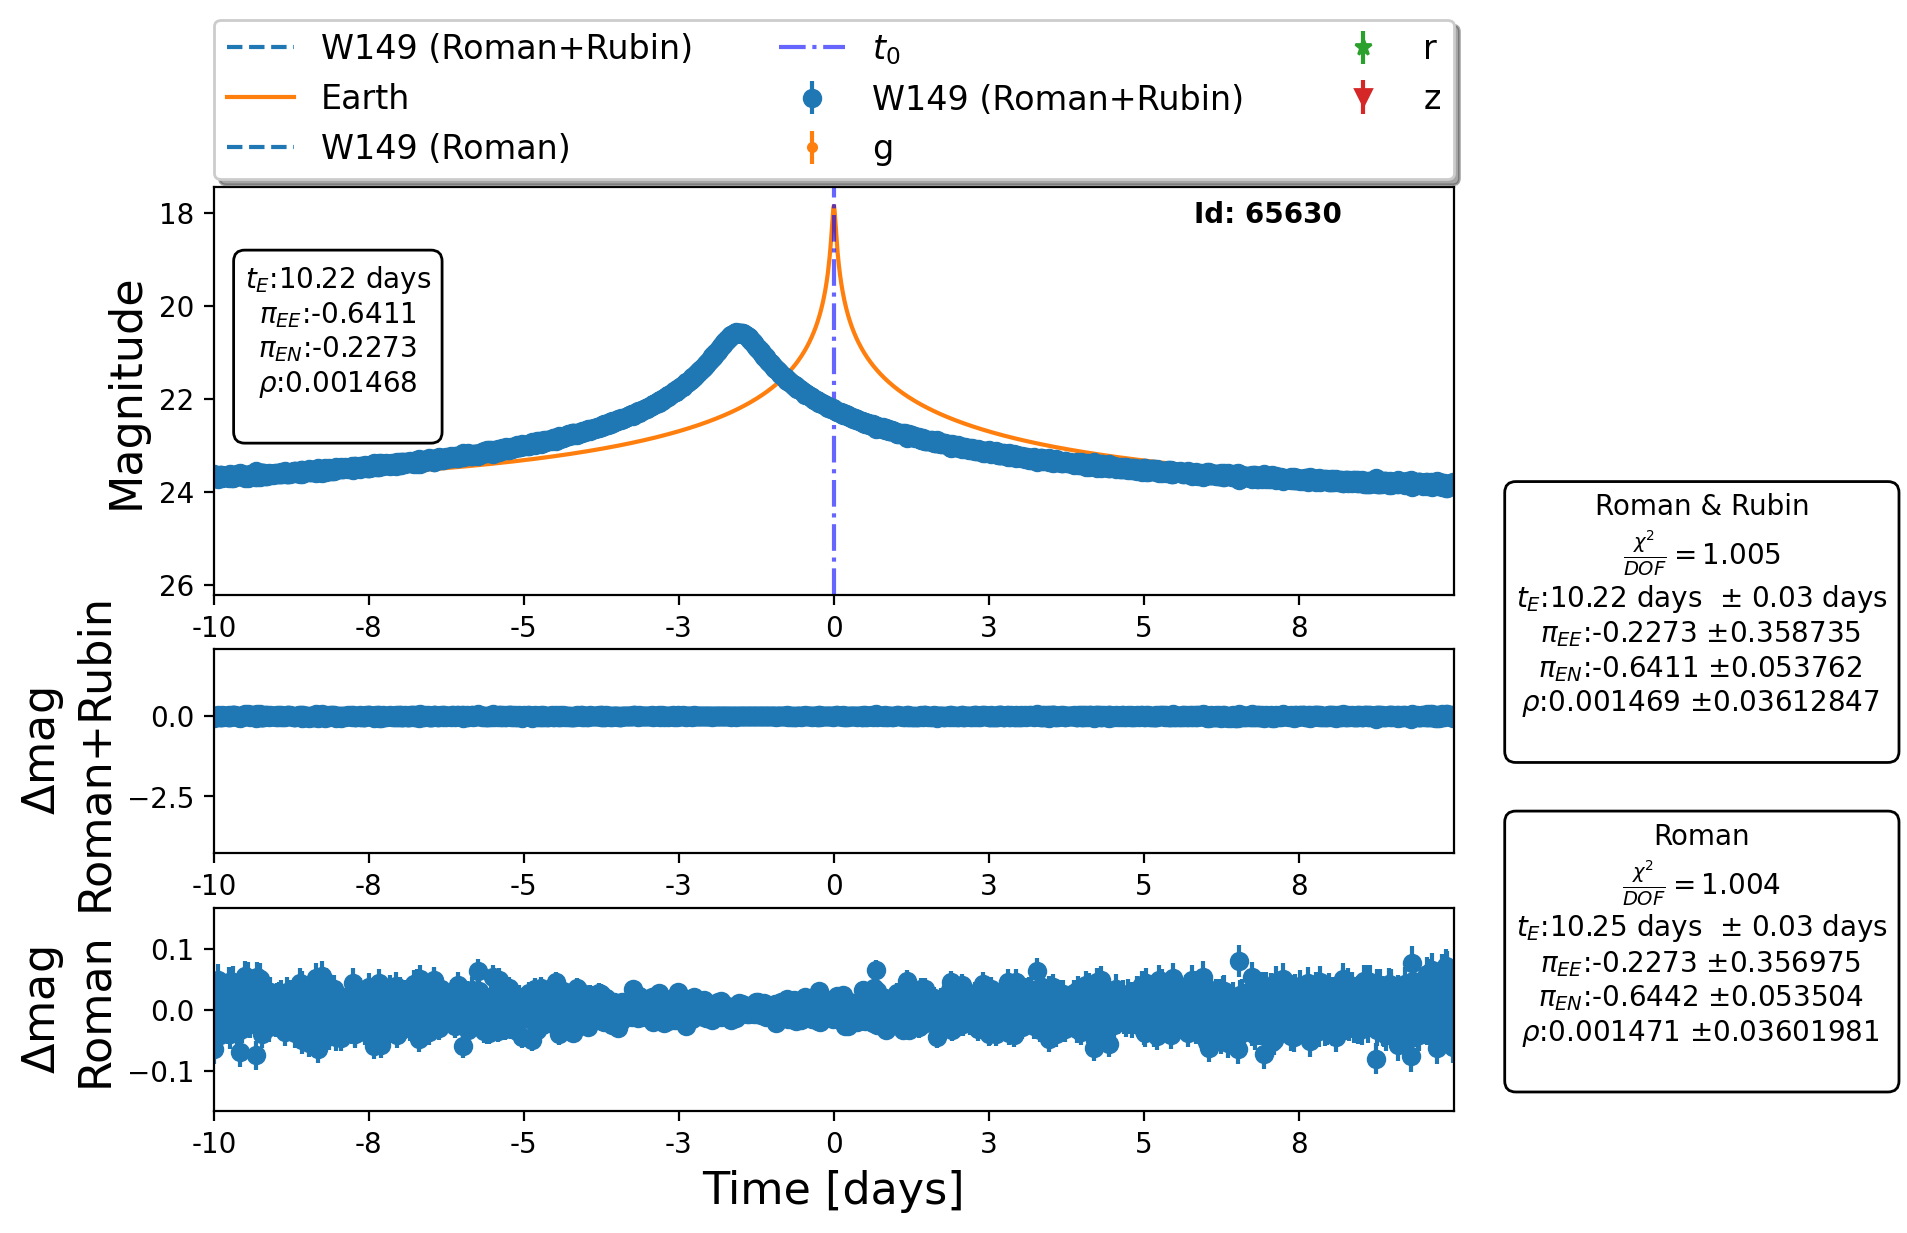

In [31]:
df_to_plot = create_df_to_plot(sources_array, category, path_save)
%matplotlib inline
graph_maker_1plot(df_to_plot, category, True)